In [ ]:
#1: Install dependencies
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [ ]:
#2: Imports
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

BLUE  = "#1a6fc4"
RED   = "#d94f3d"

print(" All libraries imported successfully.")

 All libraries imported successfully.


In [ ]:
from google.colab import files
uploaded = files.upload()          # <- pick Training_Dataset.arff

filename = list(uploaded.keys())[0]
raw_text = uploaded[filename].decode("utf-8")
data_arff, meta = arff.loadarff(io.StringIO(raw_text))

df_raw = pd.DataFrame(data_arff)
df_raw = df_raw.apply(
    lambda col: col.map(lambda x: int(x) if isinstance(x, bytes) else int(x))
)

print(f" Dataset loaded:  {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns")

Saving Training Dataset.arff to Training Dataset.arff
 Dataset loaded:  11,055 rows  ×  31 columns


In [ ]:
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)

print(f"\n📐 Shape           : {df_raw.shape[0]:,} instances × {df_raw.shape[1]} columns")
print(f"🏷️  Features (X)    : {df_raw.shape[1] - 1}  (columns 1–30)")
print(f"🎯 Target column   : 'Result'  (−1 = Phishing,  +1 = Legitimate)")

print("\n── Column Names ──────────────────────────────────────")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>2}. {col}")

print("\n── First 5 Rows ──────────────────────────────────────")
display(df_raw.head())

print("\n── Last 5 Rows ───────────────────────────────────────")
display(df_raw.tail())

print("\n── Data Types ────────────────────────────────────────")
display(df_raw.dtypes.rename("dtype").to_frame())

print("\n── Basic Statistics ──────────────────────────────────")
display(df_raw.describe())

print("\n── Target Distribution ───────────────────────────────")
vc = df_raw["Result"].value_counts()
print(f"  Legitimate (+1) : {vc[1]:,}  ({vc[1]/len(df_raw)*100:.1f}%)")
print(f"  Phishing   (−1) : {vc[-1]:,}  ({vc[-1]/len(df_raw)*100:.1f}%)")

print("\n── Unique Values Per Feature ─────────────────────────")
for col in df_raw.columns:
    print(f"  {col:<35} : {sorted(df_raw[col].unique())}")


  DATASET OVERVIEW

📐 Shape           : 11,055 instances × 31 columns
🏷️  Features (X)    : 30  (columns 1–30)
🎯 Target column   : 'Result'  (−1 = Phishing,  +1 = Legitimate)

── Column Names ──────────────────────────────────────
   1. having_IP_Address
   2. URL_Length
   3. Shortining_Service
   4. having_At_Symbol
   5. double_slash_redirecting
   6. Prefix_Suffix
   7. having_Sub_Domain
   8. SSLfinal_State
   9. Domain_registeration_length
  10. Favicon
  11. port
  12. HTTPS_token
  13. Request_URL
  14. URL_of_Anchor
  15. Links_in_tags
  16. SFH
  17. Submitting_to_email
  18. Abnormal_URL
  19. Redirect
  20. on_mouseover
  21. RightClick
  22. popUpWidnow
  23. Iframe
  24. age_of_domain
  25. DNSRecord
  26. web_traffic
  27. Page_Rank
  28. Google_Index
  29. Links_pointing_to_page
  30. Statistical_report
  31. Result

── First 5 Rows ──────────────────────────────────────


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1



── Last 5 Rows ───────────────────────────────────────


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
11050,1,-1,1,-1,1,1,1,1,-1,-1,...,-1,-1,1,1,-1,-1,1,1,1,1
11051,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,-1,1,1,1,1,1,1,-1,1,-1
11052,1,-1,1,1,1,-1,1,-1,-1,1,...,1,1,1,1,1,-1,1,0,1,-1
11053,-1,-1,1,1,1,-1,-1,-1,1,-1,...,-1,1,1,1,1,-1,1,1,1,-1
11054,-1,-1,1,1,1,-1,-1,-1,1,1,...,1,1,-1,1,-1,-1,-1,1,-1,-1



── Data Types ────────────────────────────────────────


,dtype
having_IP_Address,int64
URL_Length,int64
Shortining_Service,int64
having_At_Symbol,int64
double_slash_redirecting,int64
Prefix_Suffix,int64
having_Sub_Domain,int64
SSLfinal_State,int64
Domain_registeration_length,int64
Favicon,int64



── Basic Statistics ──────────────────────────────────


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



── Target Distribution ───────────────────────────────
  Legitimate (+1) : 6,157  (55.7%)
  Phishing   (−1) : 4,898  (44.3%)

── Unique Values Per Feature ─────────────────────────
  having_IP_Address                   : [np.int64(-1), np.int64(1)]
  URL_Length                          : [np.int64(-1), np.int64(0), np.int64(1)]
  Shortining_Service                  : [np.int64(-1), np.int64(1)]
  having_At_Symbol                    : [np.int64(-1), np.int64(1)]
  double_slash_redirecting            : [np.int64(-1), np.int64(1)]
  Prefix_Suffix                       : [np.int64(-1), np.int64(1)]
  having_Sub_Domain                   : [np.int64(-1), np.int64(0), np.int64(1)]
  SSLfinal_State                      : [np.int64(-1), np.int64(0), np.int64(1)]
  Domain_registeration_length         : [np.int64(-1), np.int64(1)]
  Favicon                             : [np.int64(-1), np.int64(1)]
  port                                : [np.int64(-1), np.int64(1)]
  HTTPS_token                  

In [ ]:
print("=" * 60)
print("  DATA QUALITY CHECK")
print("=" * 60)

missing = df_raw.isnull().sum()
dupes   = df_raw.duplicated().sum()

print(f"\n Missing values (total)  : {missing.sum()}")
print(f"  Duplicate rows          : {dupes:,}  ({dupes/len(df_raw)*100:.1f}% of dataset)")

if missing.sum() == 0:
    print("\n No missing values found. Dataset is complete.")
else:
    print("\n  Missing values detected per column:")
    display(missing[missing > 0].to_frame("missing_count"))

  DATA QUALITY CHECK

 Missing values (total)  : 0
  Duplicate rows          : 5,206  (47.1% of dataset)

 No missing values found. Dataset is complete.


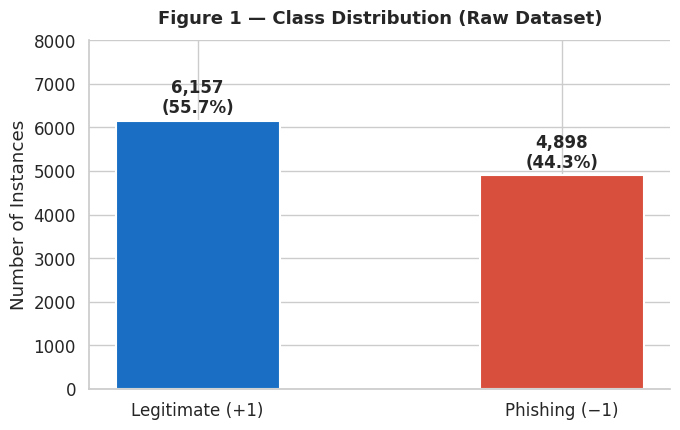

 Figure 1 saved.


In [ ]:
#6: Figure 1 — Class Distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = df_raw["Result"].value_counts()
labels = ["Legitimate (+1)", "Phishing (−1)"]
values = [counts[1], counts[-1]]
bars = ax.bar(labels, values, color=[BLUE, RED],
              width=0.45, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f"{val:,}\n({val/sum(values)*100:.1f}%)",
            ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_title("Figure 1 — Class Distribution (Raw Dataset)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of Instances")
ax.set_ylim(0, 8000)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig1_class_distribution_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 1 saved.")

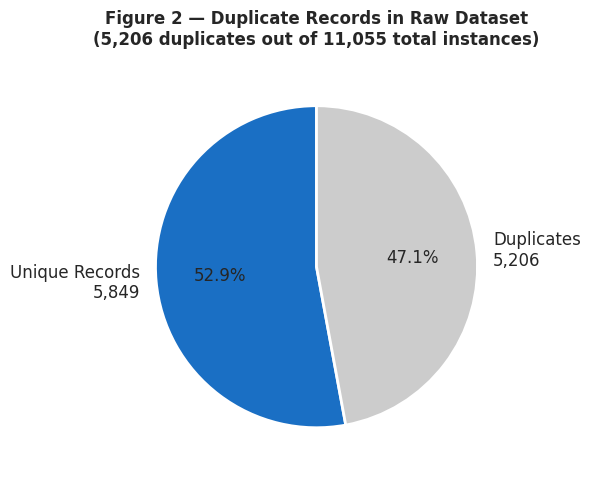

 Figure 2 saved.


In [ ]:
#7: Figure 2 — Duplicate Records Pie Chart
dupes  = df_raw.duplicated().sum()
unique = len(df_raw) - dupes

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([unique, dupes],
       labels=[f"Unique Records\n{unique:,}", f"Duplicates\n{dupes:,}"],
       colors=[BLUE, "#cccccc"],
       autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2),
       textprops=dict(fontsize=12))
ax.set_title(
    f"Figure 2 — Duplicate Records in Raw Dataset\n"
    f"({dupes:,} duplicates out of {len(df_raw):,} total instances)",
    fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("fig2_duplicate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 2 saved.")


In [ ]:
#8: Preprocessing
print("=" * 60)
print("  PREPROCESSING STEPS")
print("=" * 60)

# Step 1 — Remove duplicates
df = df_raw.drop_duplicates().copy()
print(f"\n Step 1 — Duplicates removed : {df_raw.duplicated().sum():,} rows dropped")
print(f"            Remaining          : {len(df):,} instances")

# Step 2 — Drop nulls (none expected)
before = len(df)
df.dropna(inplace=True)
print(f"\n Step 2 — Null rows removed  : {before - len(df)}")

# Step 3 — Remap labels: -1 → 0 (phishing),  1 → 1 (legitimate)
df["Result"] = df["Result"].map({-1: 0, 1: 1})
print(f"\n Step 3 — Labels remapped    : −1 → 0 (Phishing),  +1 → 1 (Legitimate)")

vc2 = df["Result"].value_counts()
print(f"\n   Phishing   (0) : {vc2.get(0,0):,}")
print(f"   Legitimate (1) : {vc2.get(1,0):,}")

print(f"\n Clean dataset shape : {df.shape}")
display(df.head())

  PREPROCESSING STEPS

 Step 1 — Duplicates removed : 5,206 rows dropped
            Remaining          : 5,849 instances

 Step 2 — Null rows removed  : 0

 Step 3 — Labels remapped    : −1 → 0 (Phishing),  +1 → 1 (Legitimate)

   Phishing   (0) : 3,019
   Legitimate (1) : 2,830

 Clean dataset shape : (5849, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,0
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,0
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,0
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,0
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


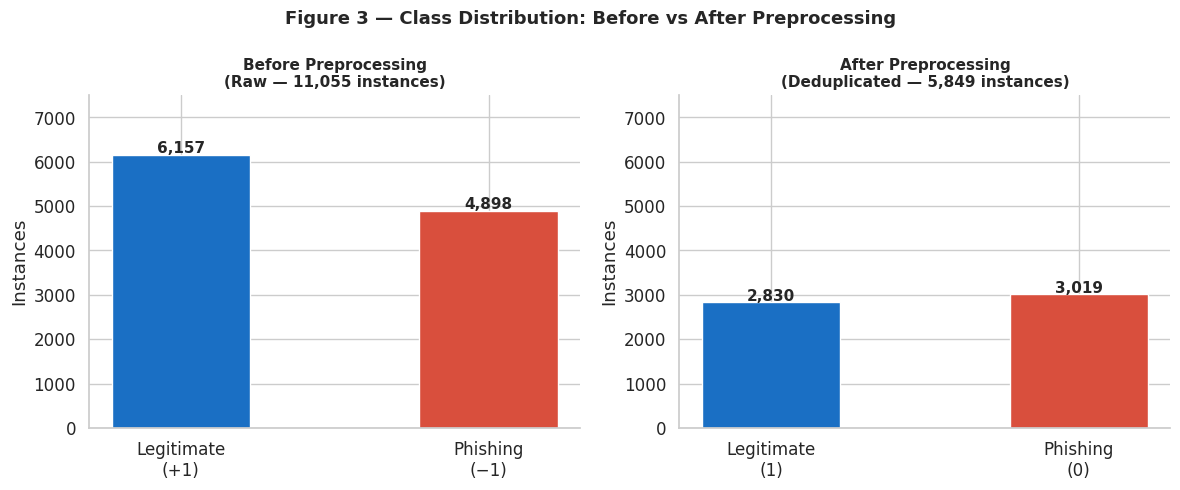

 Figure 3 saved.


In [ ]:
#9: Figure 3 — Class Distribution Before vs After
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
vc_raw = df_raw["Result"].value_counts()
axes[0].bar(["Legitimate\n(+1)", "Phishing\n(−1)"],
            [vc_raw[1], vc_raw[-1]],
            color=[BLUE, RED], edgecolor="white", width=0.45)
for bar, v in zip(axes[0].patches, [vc_raw[1], vc_raw[-1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
                 f"{v:,}", ha="center", fontweight="bold", fontsize=11)
axes[0].set_title("Before Preprocessing\n(Raw — 11,055 instances)",
                  fontweight="bold", fontsize=11)
axes[0].set_ylabel("Instances"); axes[0].set_ylim(0, 7500)
axes[0].spines[["top","right"]].set_visible(False)

# After
vc_clean = df["Result"].value_counts()
axes[1].bar(["Legitimate\n(1)", "Phishing\n(0)"],
            [vc_clean.get(1,0), vc_clean.get(0,0)],
            color=[BLUE, RED], edgecolor="white", width=0.45)
for bar, v in zip(axes[1].patches, [vc_clean.get(1,0), vc_clean.get(0,0)]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+25,
                 f"{v:,}", ha="center", fontweight="bold", fontsize=11)
axes[1].set_title(f"After Preprocessing\n(Deduplicated — {len(df):,} instances)",
                  fontweight="bold", fontsize=11)
axes[1].set_ylabel("Instances"); axes[1].set_ylim(0, 7500)
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("Figure 3 — Class Distribution: Before vs After Preprocessing",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_class_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 3 saved.")

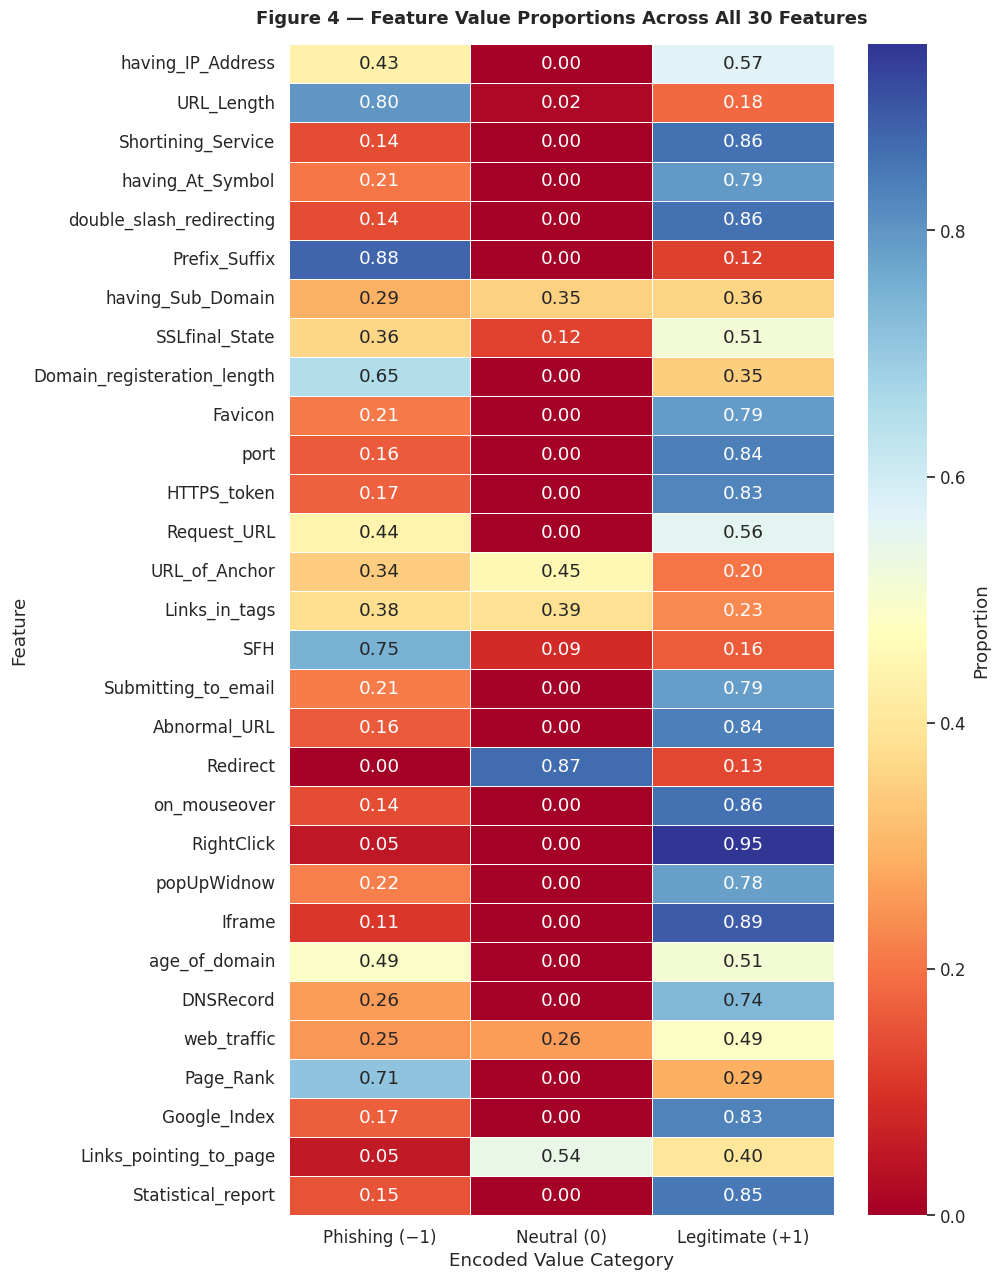

 Figure 4 saved.


In [ ]:
# 10: Figure 4 — Feature Value Heatmap
features = [c for c in df.columns if c != "Result"]

val_matrix = pd.DataFrame({
    f: df[f].value_counts(normalize=True) for f in features
}).T.fillna(0)

for col_name in ["Phishing (−1)", "Neutral (0)", "Legitimate (+1)"]:
    pass  # just prep

rename_map = {}
if -1 in val_matrix.columns: rename_map[-1] = "Phishing (−1)"
if  0 in val_matrix.columns: rename_map[0]  = "Neutral (0)"
if  1 in val_matrix.columns: rename_map[1]  = "Legitimate (+1)"
val_matrix = val_matrix.rename(columns=rename_map)

for col_name in ["Phishing (−1)", "Neutral (0)", "Legitimate (+1)"]:
    if col_name not in val_matrix.columns:
        val_matrix[col_name] = 0.0
val_matrix = val_matrix[["Phishing (−1)", "Neutral (0)", "Legitimate (+1)"]]

fig, ax = plt.subplots(figsize=(10, 13))
sns.heatmap(val_matrix, annot=True, fmt=".2f", cmap="RdYlBu",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Proportion"})
ax.set_title("Figure 4 — Feature Value Proportions Across All 30 Features",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Encoded Value Category"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("fig4_feature_value_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 4 saved.")

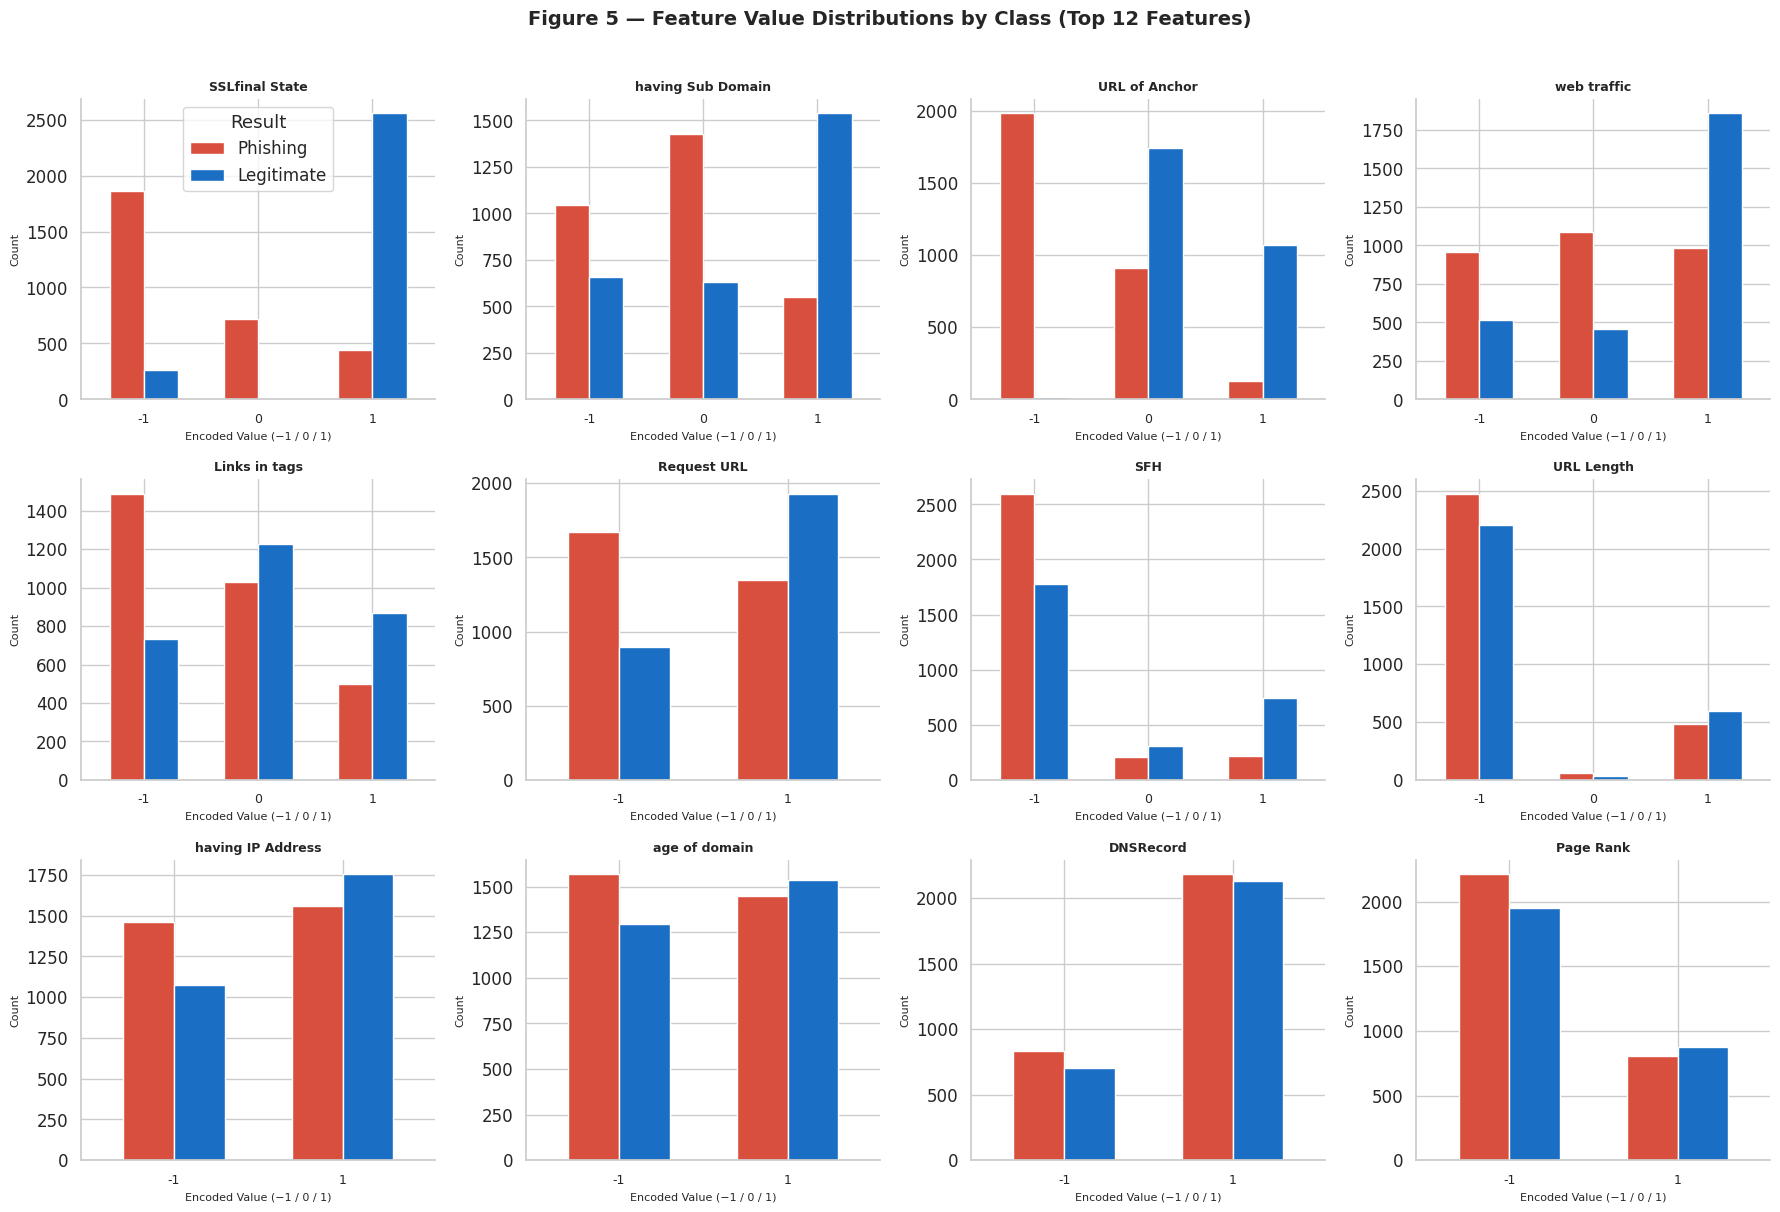

 Figure 5 saved.


In [ ]:
#11: Figure 5 — Feature Distributions by Class
top_features = [
    "SSLfinal_State", "having_Sub_Domain", "URL_of_Anchor",
    "web_traffic", "Links_in_tags", "Request_URL",
    "SFH", "URL_Length", "having_IP_Address", "age_of_domain",
    "DNSRecord", "Page_Rank"
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    grouped = (df.groupby([feat, "Result"])
                 .size()
                 .unstack(fill_value=0))
    rename = {}
    if 0 in grouped.columns: rename[0] = "Phishing"
    if 1 in grouped.columns: rename[1] = "Legitimate"
    grouped = grouped.rename(columns=rename)
    colors_use = []
    if "Phishing"   in grouped.columns: colors_use.append(RED)
    if "Legitimate" in grouped.columns: colors_use.append(BLUE)
    grouped.plot(kind="bar", ax=ax, color=colors_use,
                 edgecolor="white", width=0.6, legend=(i == 0))
    ax.set_title(feat.replace("_", " "), fontsize=9, fontweight="bold")
    ax.set_xlabel("Encoded Value (−1 / 0 / 1)", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle(
    "Figure 5 — Feature Value Distributions by Class (Top 12 Features)",
    fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig5_feature_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 5 saved.")


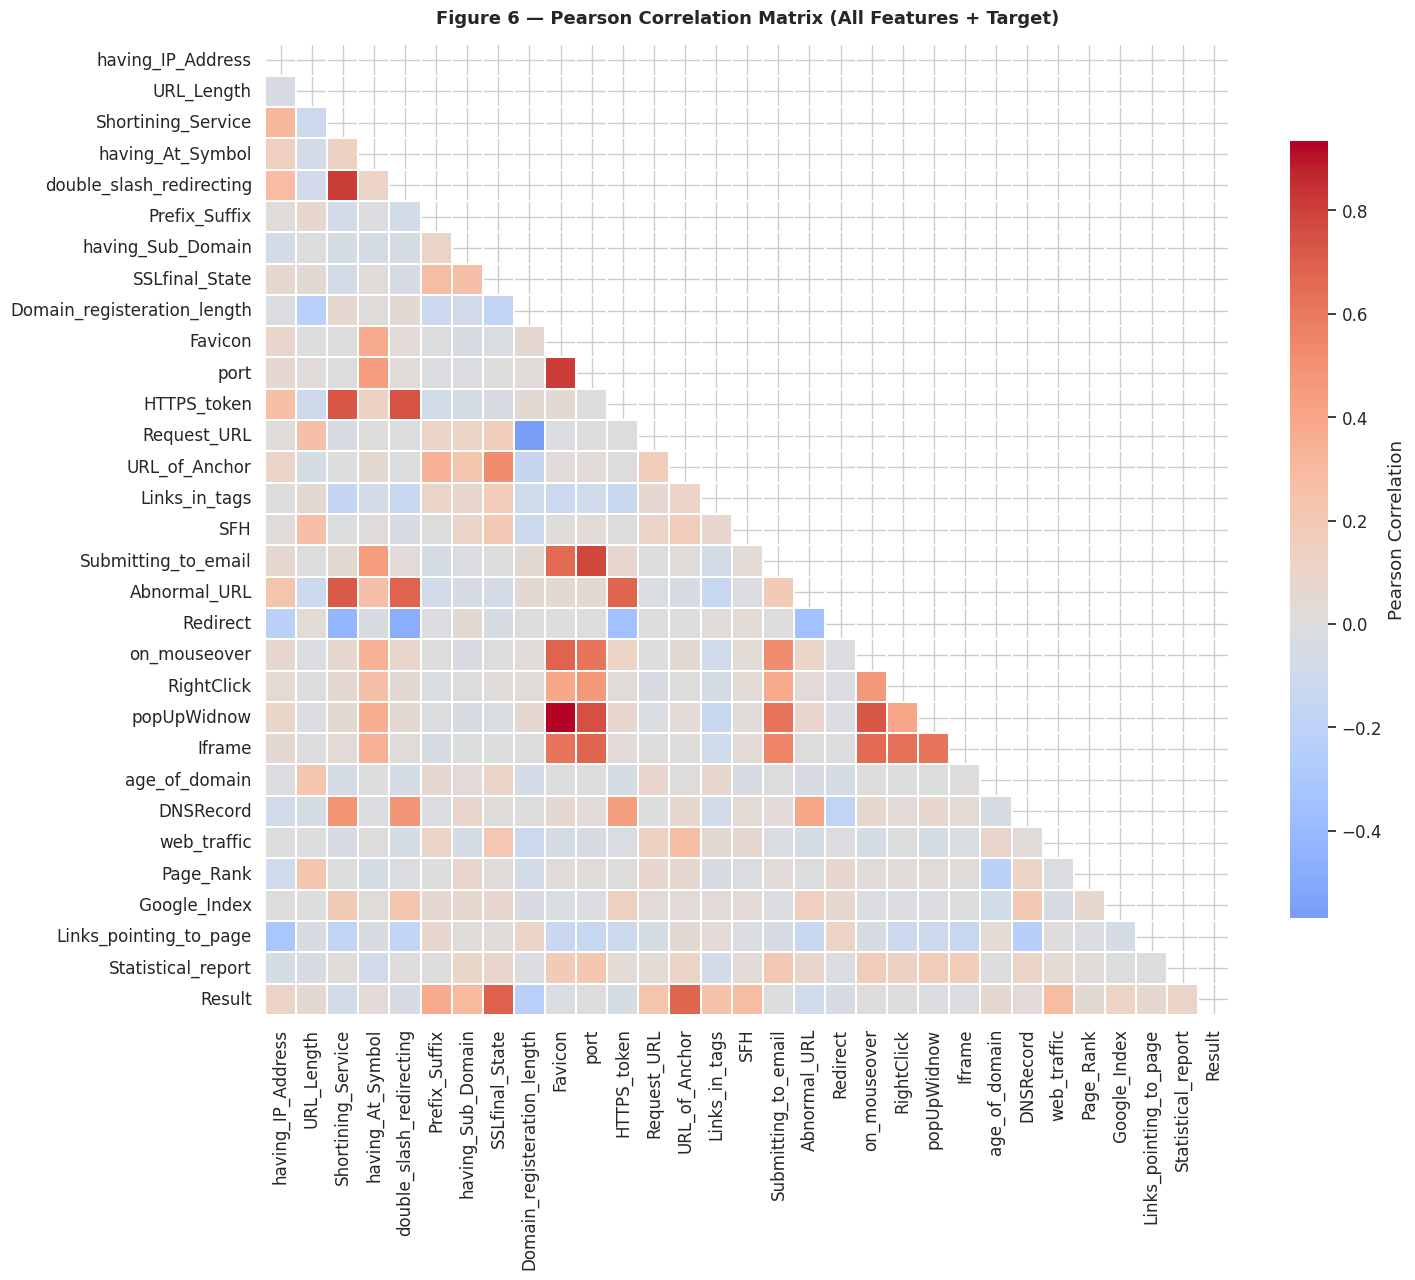

 Figure 6 saved.


In [ ]:
#12: Figure 6 — Correlation Matrix
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
ax.set_title("Figure 6 — Pearson Correlation Matrix (All Features + Target)",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("fig6_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 6 saved.")

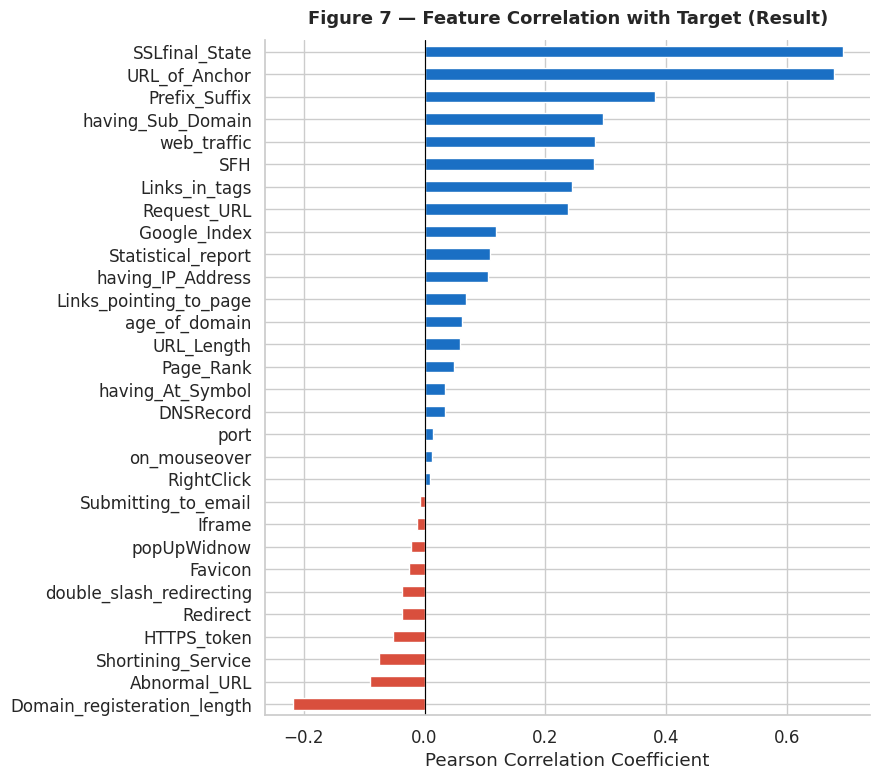

 Figure 7 saved.

 Top 5 features most correlated with LEGITIMATE:


,correlation
web_traffic,0.281709
having_Sub_Domain,0.296214
Prefix_Suffix,0.381134
URL_of_Anchor,0.679125
SSLfinal_State,0.693228



 Top 5 features most correlated with PHISHING:


,correlation
Domain_registeration_length,-0.218623
Abnormal_URL,-0.090043
Shortining_Service,-0.076166
HTTPS_token,-0.051412
Redirect,-0.037462


In [ ]:
#13: Figure 7 — Feature Correlation with Target ─────
target_corr = df.corr()["Result"].drop("Result").sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors_bar = [RED if v < 0 else BLUE for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Figure 7 — Feature Correlation with Target (Result)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Pearson Correlation Coefficient")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig7_target_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 7 saved.")

print("\n Top 5 features most correlated with LEGITIMATE:")
display(target_corr.tail(5).to_frame("correlation"))

print("\n Top 5 features most correlated with PHISHING:")
display(target_corr.head(5).to_frame("correlation"))


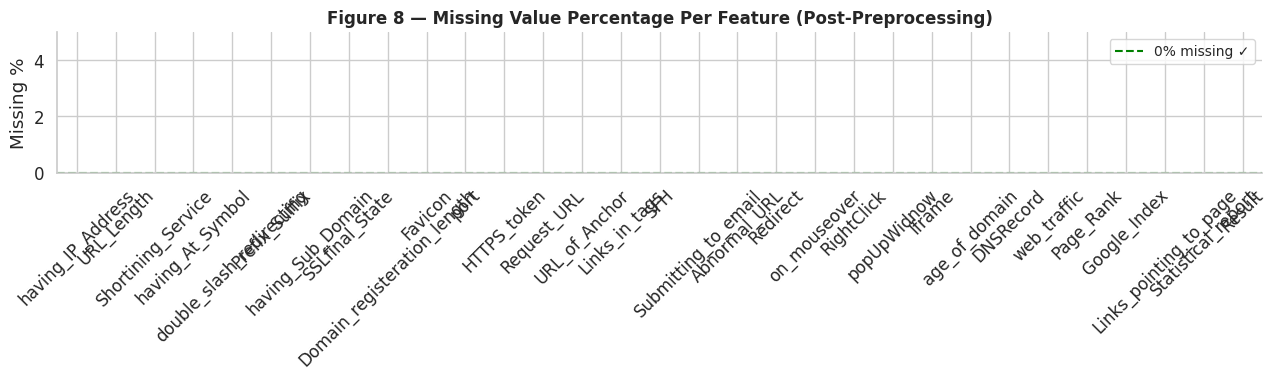

 Figure 8 saved.


In [ ]:
#  14: Figure 8 — Missing Values Confirmation
missing_pct = df.isnull().sum() / len(df) * 100

fig, ax = plt.subplots(figsize=(13, 4))
missing_pct.plot(kind="bar", ax=ax, color=BLUE, edgecolor="white")
ax.set_title(
    "Figure 8 — Missing Value Percentage Per Feature (Post-Preprocessing)",
    fontsize=12, fontweight="bold")
ax.set_ylabel("Missing %"); ax.set_ylim(0, 5)
ax.axhline(0, color="green", linestyle="--", linewidth=1.5, label="0% missing ✓")
ax.legend(fontsize=10); ax.tick_params(axis="x", rotation=45)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig8_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 8 saved.")

In [ ]:
# CELL 15: Feature Scaling + Train/Test Split
X = df.drop(columns=["Result"])
y = df["Result"]

# MinMax Normalisation
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("=" * 60)
print("  FEATURE SCALING & TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n Scaling     : MinMax Normalisation applied → values in [0, 1]")
print(f" Split ratio : 80% train / 20% test  (stratified, random_state=42)")
print(f"\n   Training set : {len(X_train):,} instances")
print(f"   Test set     : {len(X_test):,}  instances")
print(f"\n   Train — Phishing: {(y_train==0).sum():,}  |  Legitimate: {(y_train==1).sum():,}")
print(f"   Test  — Phishing: {(y_test==0).sum():,}   |  Legitimate: {(y_test==1).sum():,}")

  FEATURE SCALING & TRAIN/TEST SPLIT

 Scaling     : MinMax Normalisation applied → values in [0, 1]
 Split ratio : 80% train / 20% test  (stratified, random_state=42)

   Training set : 4,679 instances
   Test set     : 1,170  instances

   Train — Phishing: 2,415  |  Legitimate: 2,264
   Test  — Phishing: 604   |  Legitimate: 566


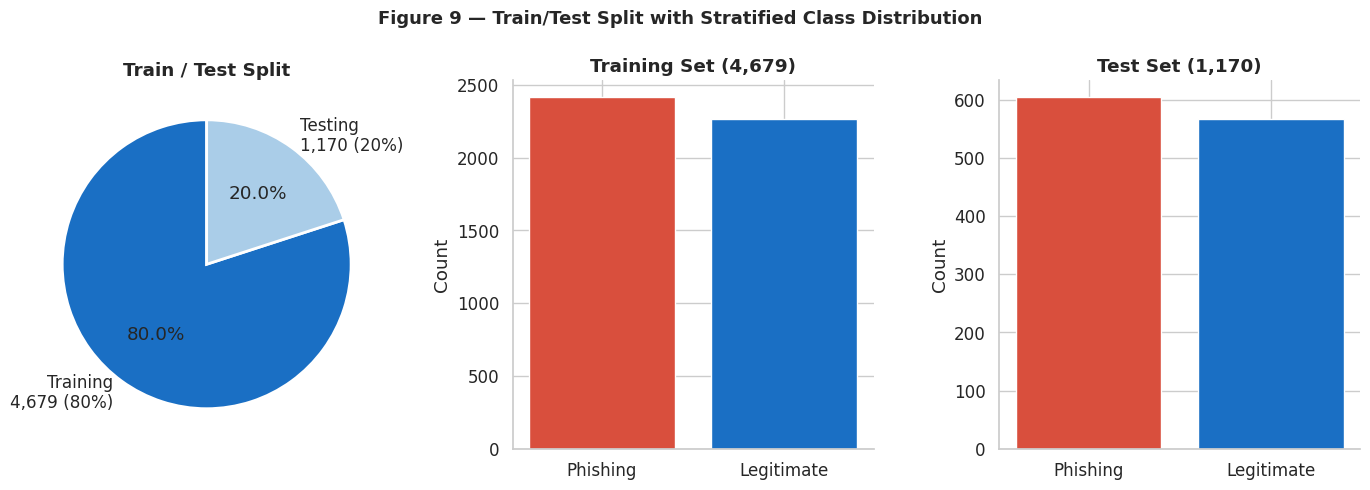

 Figure 9 saved.


In [ ]:
# 16: Figure 9 — Train/Test Split Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].pie(
    [len(X_train), len(X_test)],
    labels=[f"Training\n{len(X_train):,} (80%)", f"Testing\n{len(X_test):,} (20%)"],
    colors=[BLUE, "#aacde8"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Train / Test Split", fontweight="bold")

tr = pd.Series(y_train).value_counts()
axes[1].bar(["Phishing", "Legitimate"],
            [tr.get(0,0), tr.get(1,0)], color=[RED, BLUE], edgecolor="white")
axes[1].set_title(f"Training Set ({len(X_train):,})", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].spines[["top","right"]].set_visible(False)

te = pd.Series(y_test).value_counts()
axes[2].bar(["Phishing", "Legitimate"],
            [te.get(0,0), te.get(1,0)], color=[RED, BLUE], edgecolor="white")
axes[2].set_title(f"Test Set ({len(X_test):,})", fontweight="bold")
axes[2].set_ylabel("Count")
axes[2].spines[["top","right"]].set_visible(False)

fig.suptitle("Figure 9 — Train/Test Split with Stratified Class Distribution",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig9_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 9 saved.")

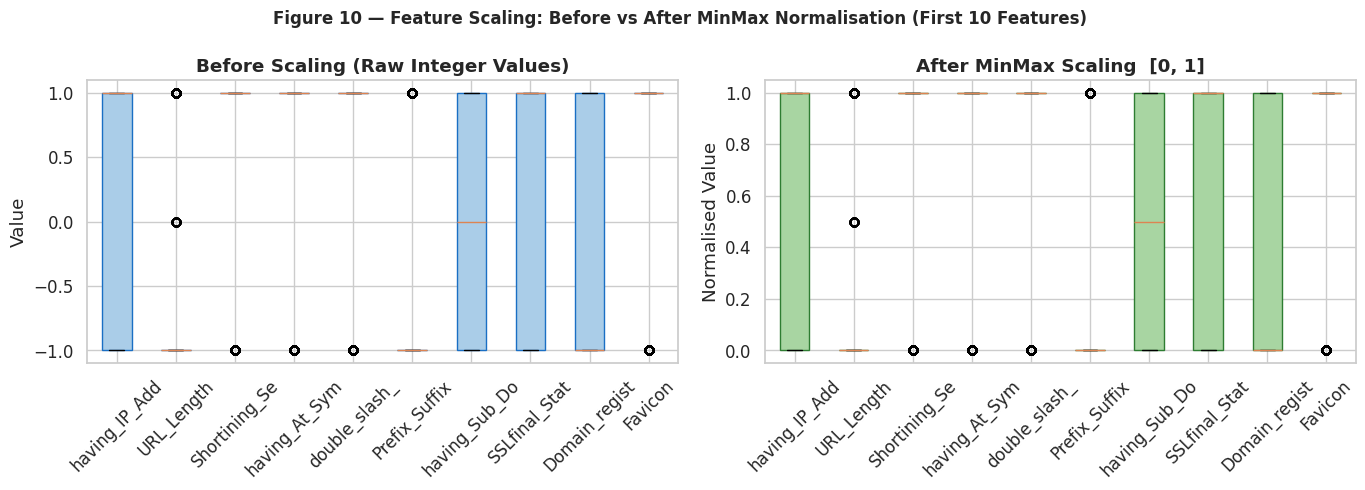

 Figure 10 saved.


In [ ]:
# 17: Figure 10 — Feature Scaling Before/After
sample_raw    = df.drop(columns=["Result"]).values[:, :10]
sample_scaled = X_scaled[:, :10]
feat_labels   = [c[:13] for c in X.columns[:10]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(sample_raw, labels=feat_labels, patch_artist=True,
                boxprops=dict(facecolor="#aacde8", color=BLUE))
axes[0].set_title("Before Scaling (Raw Integer Values)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45); axes[0].set_ylabel("Value")

axes[1].boxplot(sample_scaled, labels=feat_labels, patch_artist=True,
                boxprops=dict(facecolor="#a8d5a2", color="#2e7d32"))
axes[1].set_title("After MinMax Scaling  [0, 1]", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45); axes[1].set_ylabel("Normalised Value")

fig.suptitle(
    "Figure 10 — Feature Scaling: Before vs After MinMax Normalisation (First 10 Features)",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig10_feature_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 10 saved.")

In [ ]:
# 18: Final Preprocessing Summary
print("=" * 60)
print("  PREPROCESSING SUMMARY")
print("=" * 60)

summary = {
    "Raw instances":                  len(df_raw),
    "Duplicate records removed":      int(df_raw.duplicated().sum()),
    "Clean instances (after dedup)":  len(df),
    "Number of features (X)":         X.shape[1],
    "Missing values remaining":       int(df.isnull().sum().sum()),
    "Phishing instances  (label 0)":  int((y == 0).sum()),
    "Legitimate instances (label 1)": int((y == 1).sum()),
    "Scaling method":                 "MinMax Normalisation [0, 1]",
    "Training set size (80%)":        len(X_train),
    "Test set size     (20%)":        len(X_test),
    "Stratified split":               "Yes  (random_state = 42)",
}

summary_df = pd.DataFrame(summary.items(), columns=["Step", "Value"])
display(summary_df)
summary_df.to_csv("preprocessing_summary.csv", index=False)
print("\n Summary saved to preprocessing_summary.csv")

  PREPROCESSING SUMMARY


,Step,Value
0,Raw instances,11055
1,Duplicate records removed,5206
2,Clean instances (after dedup),5849
3,Number of features (X),30
4,Missing values remaining,0
5,Phishing instances (label 0),3019
6,Legitimate instances (label 1),2830
7,Scaling method,"MinMax Normalisation [0, 1]"
8,Training set size (80%),4679
9,Test set size (20%),1170



 Summary saved to preprocessing_summary.csv


In [ ]:
#19: Download All Saved Figures
from google.colab import files
import os

figures = [f for f in os.listdir(".") if f.endswith(".png") or f.endswith(".csv")]
print(" Files available for download:")
for f in sorted(figures):
    print(f"   {f}")

print("\nDownloading all figures and summary...")
for f in sorted(figures):
    files.download(f)

print("\n All done! Figures and summary downloaded.")

 Files available for download:
   fig10_feature_scaling.png
   fig1_class_distribution_raw.png
   fig2_duplicate_analysis.png
   fig3_class_before_after.png
   fig5_feature_by_class.png
   fig6_correlation_matrix.png
   fig7_target_correlation.png
   fig8_missing_values.png
   fig9_train_test_split.png
   preprocessing_summary.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 All done! Figures and summary downloaded.


# **Training**

**Install & Import (for training phase)**

In [ ]:
#Install XGBoost and import training libraries
!pip install xgboost -q

import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

print(" Training libraries ready.")

 Training libraries ready.


**Training All 5 Models**

In [ ]:
#Define and training all 5 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes":         GaussianNB(),
    "XGBoost":             XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42),
}

trained_models = {}
for name, model in models.items():
    print(f" Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"    Done.")

print("\n All 5 models trained!")

 Training Logistic Regression...
    Done.
 Training SVM...
    Done.
 Training Random Forest...
    Done.
 Training Naive Bayes...
    Done.
 Training XGBoost...
    Done.

 All 5 models trained!


**Evaluate & Compare**

In [ ]:
#Evaluate all models and display comparison table
results = []
for name, model in trained_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred),  4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred),    4),
        "F1 Score":  round(f1_score(y_test, y_pred),        4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba),  4),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("\n Model Comparison:\n")
print(results_df.to_string(index=False))


 Model Comparison:

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
            XGBoost    0.9521     0.9537  0.9470    0.9504   0.9933
      Random Forest    0.9419     0.9368  0.9435    0.9401   0.9881
                SVM    0.9359     0.9168  0.9541    0.9351   0.9819
Logistic Regression    0.9128     0.9000  0.9223    0.9110   0.9734
        Naive Bayes    0.6547     0.9939  0.2880    0.4466   0.9635


**Bar Chart**

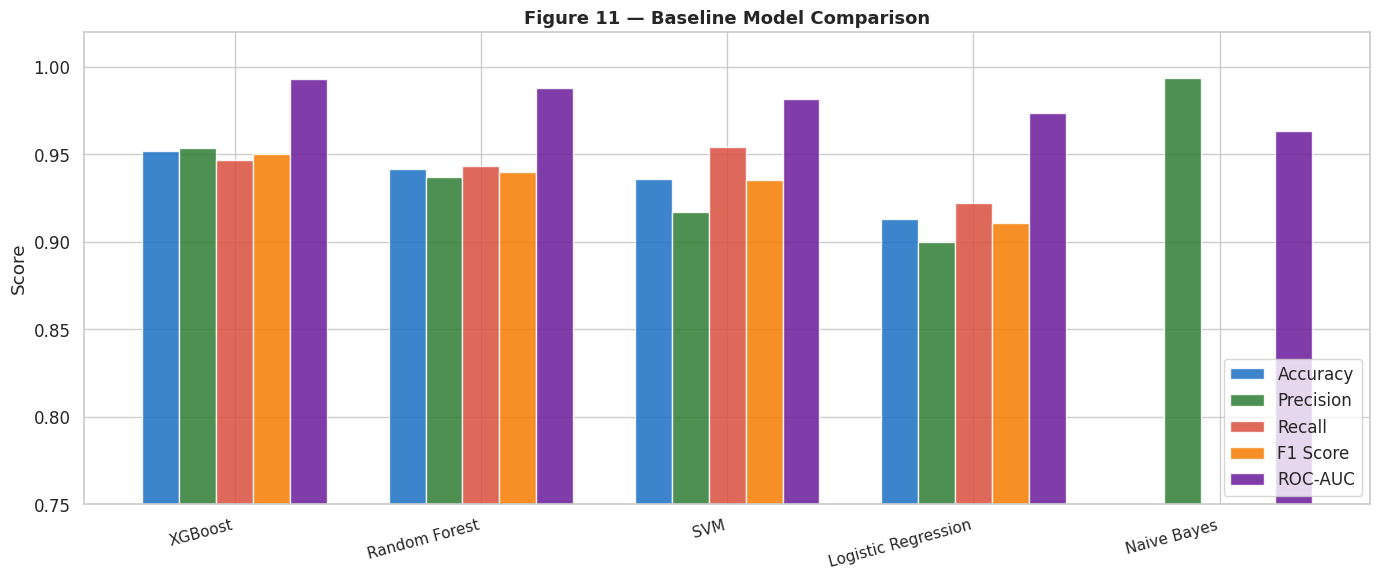

Figure 11 saved.


In [ ]:
#Grouped bar chart of all metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
colors  = ["#1a6fc4", "#2e7d32", "#d94f3d", "#f57c00", "#6a1b9a"]
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right", fontsize=11)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel("Score")
ax.set_title("Figure 11 — Baseline Model Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig11_model_comparison.png", dpi=150)
plt.show()
print("Figure 11 saved.")

**Confusion Matrices**

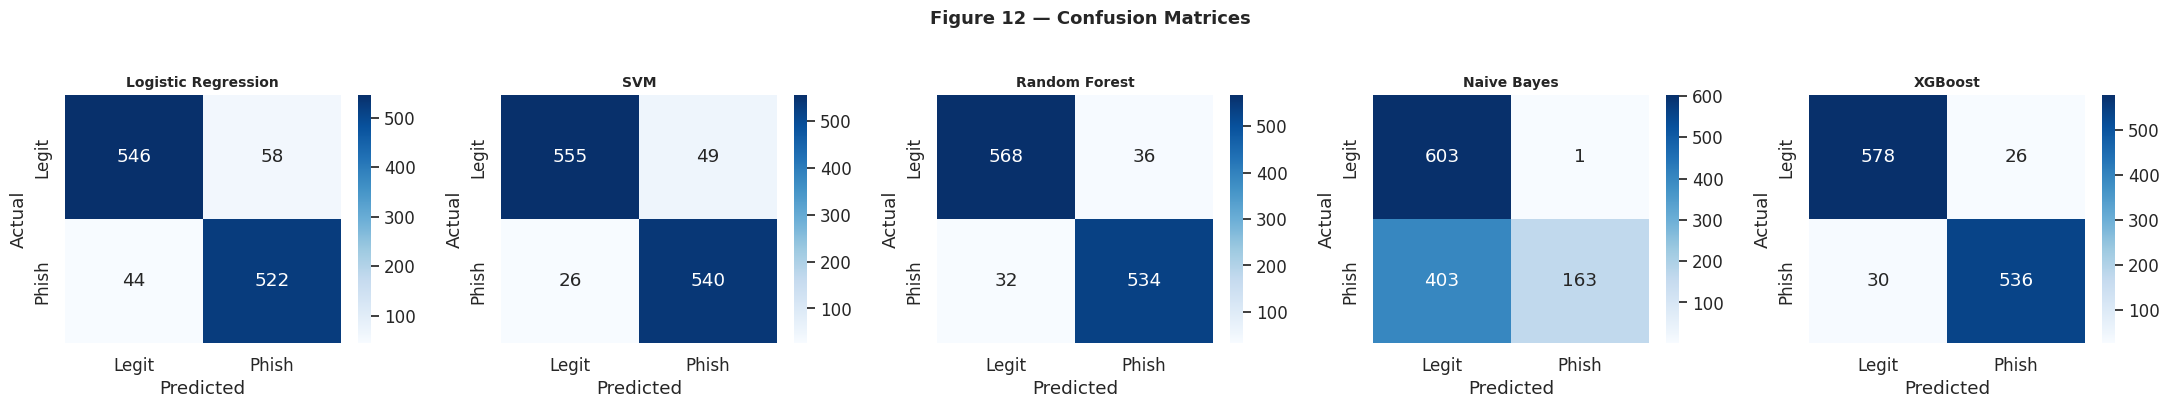

 Figure 12 saved.


In [ ]:
#Confusion matrices for all 5 models
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Phish"],
                yticklabels=["Legit", "Phish"])
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Figure 12 — Confusion Matrices", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig12_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure 12 saved.")

**ROC Curves**

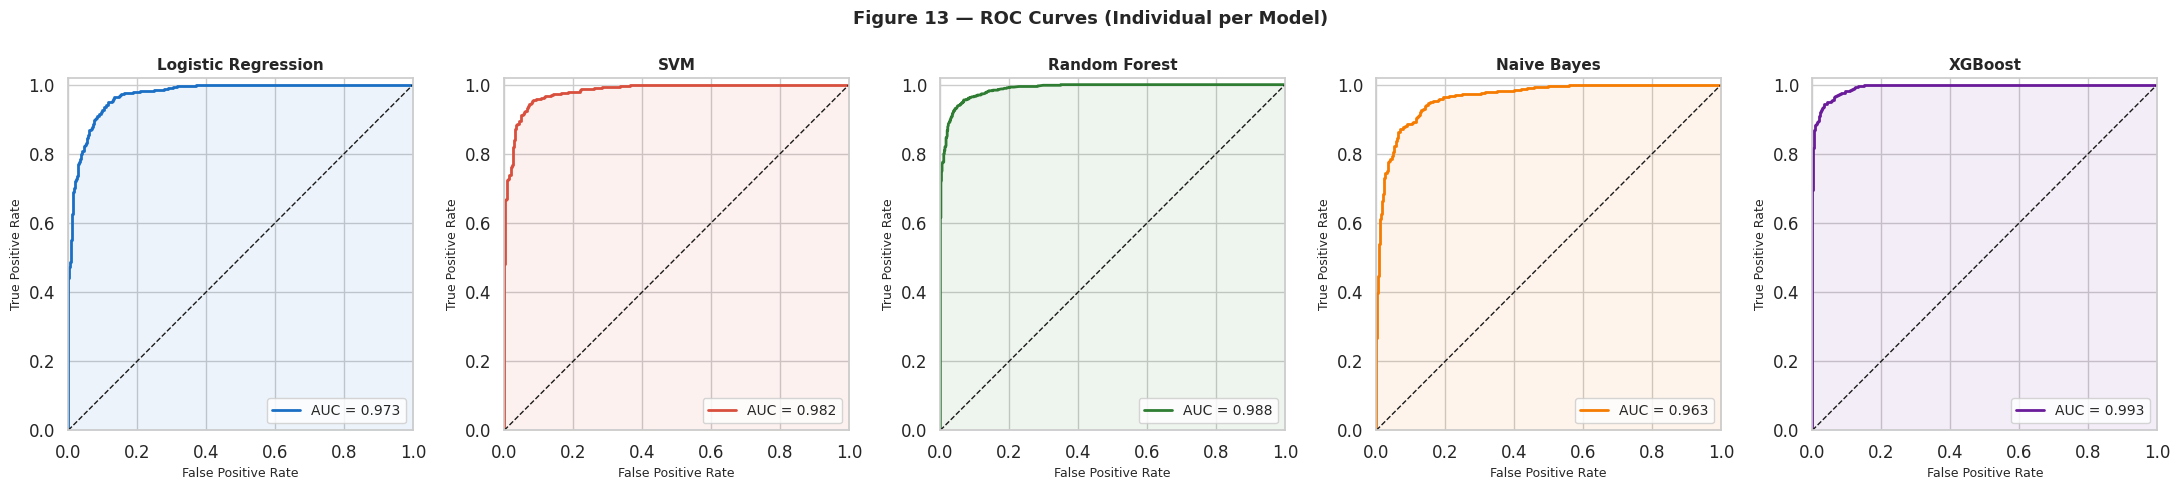

Figure 13 saved.


In [ ]:
#ROC Curves for each model
colors = ["#1a6fc4", "#d94f3d", "#2e7d32", "#f57c00", "#6a1b9a"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (name, model), color in zip(axes, trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    ax.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)

    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.legend(loc="lower right", fontsize=10)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.suptitle("Figure 13 — ROC Curves (Individual per Model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig13_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 13 saved.")

**Save Best Model**

In [ ]:
# Save best model, scaler, and feature names
import joblib, os

# Display all models across all metrics ──
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

print("📊 Model Performance Summary:")
print("-" * 75)
print(f"  {'Model':<25} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1 Score':>9} {'ROC-AUC':>9}")
print("-" * 75)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<25} {row['Accuracy']:>9.4f} {row['Precision']:>9.4f} {row['Recall']:>9.4f} {row['F1 Score']:>9.4f} {row['ROC-AUC']:>9.4f}")
print("-" * 75)

# Select best model by ROC-AUC ──
best_row   = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]
best_name  = best_row["Model"]
best_model = trained_models[best_name]

print(f"\n Best Model  : {best_name}  (selected by ROC-AUC)")
print(f"   Accuracy   : {best_row['Accuracy']:.4f}")
print(f"   Precision  : {best_row['Precision']:.4f}")
print(f"   Recall     : {best_row['Recall']:.4f}")
print(f"   F1 Score   : {best_row['F1 Score']:.4f}")
print(f"   ROC-AUC    : {best_row['ROC-AUC']:.4f}")

# ── Fix: define feature_names from dataframe columns ──
feature_names = list(X.columns)
print(f"\n Feature names captured: {len(feature_names)} features")

# ── Save to Google Drive ──
save_dir = "/content/"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_model,    f"{save_dir}/best_model.pkl")
joblib.dump(scaler,        f"{save_dir}/scaler.pkl")
joblib.dump(feature_names, f"{save_dir}/feature_names.pkl")

print(f"\n Files saved to: {save_dir}")
print(f"    best_model.pkl     → trained {best_name} model")
print(f"    scaler.pkl         ")
print(f"    feature_names.pkl  ")

# ── Verify files saved correctly ──
print("\n Verification:")
for fname in ["best_model.pkl", "scaler.pkl", "feature_names.pkl"]:
    path = f"{save_dir}/{fname}"
    size = os.path.getsize(path)
    print(f"   {fname} saved")

📊 Model Performance Summary:
---------------------------------------------------------------------------
  Model                      Accuracy Precision    Recall  F1 Score   ROC-AUC
---------------------------------------------------------------------------
  XGBoost                      0.9521    0.9537    0.9470    0.9504    0.9933
  Random Forest                0.9419    0.9368    0.9435    0.9401    0.9881
  SVM                          0.9359    0.9168    0.9541    0.9351    0.9819
  Logistic Regression          0.9128    0.9000    0.9223    0.9110    0.9734
  Naive Bayes                  0.6547    0.9939    0.2880    0.4466    0.9635
---------------------------------------------------------------------------

 Best Model  : XGBoost  (selected by ROC-AUC)
   Accuracy   : 0.9521
   Precision  : 0.9537
   Recall     : 0.9470
   F1 Score   : 0.9504
   ROC-AUC    : 0.9933

 Feature names captured: 30 features

 Files saved to: /content/
    best_model.pkl     → trained XGBoost model


# **Hyper Parameter Tuning**

**Install & Import**

In [ ]:
#Imports for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import time

print(" Tuning libraries ready.")

 Tuning libraries ready.


**Define Parameter Grids**

In [ ]:
# Define hyperparameter grids for all 5 models
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C":       [0.01, 0.1, 1, 10],
            "solver":  ["lbfgs", "liblinear"],
            "penalty": ["l2"]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C":      [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma":  ["scale", "auto"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth":    [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric="logloss", random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth":    [3, 5, 7],
            "learning_rate":[0.01, 0.1, 0.2],
            "subsample":    [0.8, 1.0]
        }
    }
}

print(" Parameter grids defined for all 5 models.")

 Parameter grids defined for all 5 models.


**Run GridSearchCV**

In [ ]:
# Run GridSearchCV for all models (scored by ROC-AUC)
tuned_models  = {}
tuning_results = []

print(" Starting hyperparameter tuning...\n")
print("=" * 60)

for name, config in param_grids.items():
    start = time.time()
    print(f" Tuning {name}...")

    grid = GridSearchCV(
        estimator  = config["model"],
        param_grid = config["params"],
        scoring    = "roc_auc",
        cv         = 5,
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)

    elapsed = round(time.time() - start, 1)
    tuned_models[name] = grid.best_estimator_

    # Evaluate on test set
    y_pred  = grid.best_estimator_.predict(X_test)
    y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

    tuning_results.append({
        "Model":        name,
        "Best Params":  grid.best_params_,
        "Accuracy":     round(accuracy_score(y_test, y_pred),  4),
        "Precision":    round(precision_score(y_test, y_pred), 4),
        "Recall":       round(recall_score(y_test, y_pred),    4),
        "F1 Score":     round(f1_score(y_test, y_pred),        4),
        "ROC-AUC":      round(roc_auc_score(y_test, y_proba),  4),
    })

    print(f"   Done in {elapsed}s  |  Best ROC-AUC: {grid.best_score_:.4f}")
    print(f"   Best Params: {grid.best_params_}\n")

print("=" * 60)
print("Tuning complete for all 5 models!")

 Starting hyperparameter tuning...

 Tuning Logistic Regression...
   Done in 5.0s  |  Best ROC-AUC: 0.9766
   Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}

 Tuning SVM...
   Done in 93.5s  |  Best ROC-AUC: 0.9877
   Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

 Tuning Random Forest...
   Done in 29.5s  |  Best ROC-AUC: 0.9902
   Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

 Tuning Naive Bayes...
   Done in 0.3s  |  Best ROC-AUC: 0.9680
   Best Params: {'var_smoothing': 1e-09}

 Tuning XGBoost...
   Done in 20.6s  |  Best ROC-AUC: 0.9923
   Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Tuning complete for all 5 models!


**Compare Tuned Results**

In [ ]:
# Compare tuned model performance
tuned_df = pd.DataFrame(tuning_results).sort_values("ROC-AUC", ascending=False)
tuned_df  = tuned_df.reset_index(drop=True)

print("Tuned Model Performance Summary:")
print("-" * 75)
print(f"  {'Model':<25} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1 Score':>9} {'ROC-AUC':>9}")
print("-" * 75)
for _, row in tuned_df.iterrows():
    print(f"  {row['Model']:<25} {row['Accuracy']:>9.4f} {row['Precision']:>9.4f} {row['Recall']:>9.4f} {row['F1 Score']:>9.4f} {row['ROC-AUC']:>9.4f}")
print("-" * 75)

Tuned Model Performance Summary:
---------------------------------------------------------------------------
  Model                      Accuracy Precision    Recall  F1 Score   ROC-AUC
---------------------------------------------------------------------------
  XGBoost                      0.9521    0.9570    0.9435    0.9502    0.9935
  Random Forest                0.9444    0.9372    0.9488    0.9429    0.9902
  SVM                          0.9453    0.9343    0.9541    0.9441    0.9881
  Logistic Regression          0.9137    0.9002    0.9240    0.9119    0.9739
  Naive Bayes                  0.6547    0.9939    0.2880    0.4466    0.9635
---------------------------------------------------------------------------


**Before vs After Tuning**

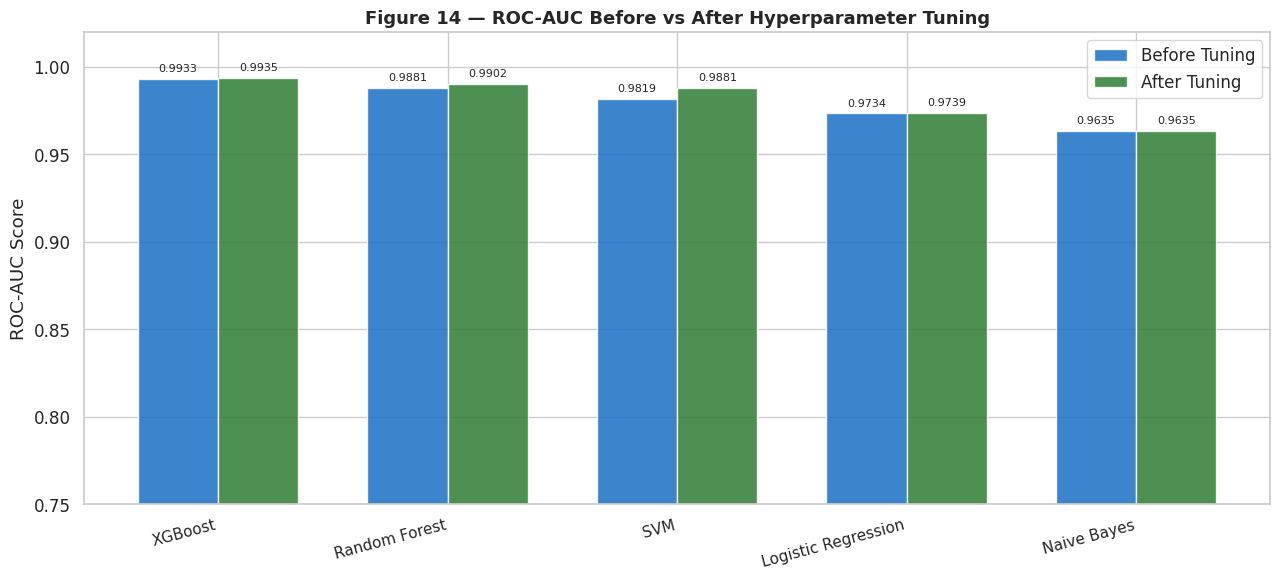

Figure 14 saved.


In [ ]:
# Before vs After Tuning comparison
model_names = results_df["Model"].tolist()
x = np.arange(len(model_names))
width = 0.35

# Align tuned_df to same model order as results_df
tuned_aligned = tuned_df.set_index("Model").reindex(model_names).reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, results_df["ROC-AUC"],      width, label="Before Tuning", color="#1a6fc4", alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_aligned["ROC-AUC"],   width, label="After Tuning",  color="#2e7d32", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=11)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel("ROC-AUC Score")
ax.set_title("Figure 14 — ROC-AUC Before vs After Hyperparameter Tuning", fontsize=13, fontweight="bold")
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("fig14_tuning_comparison.png", dpi=150)
plt.show()
print("Figure 14 saved.")

**Save Best Tuned Model**

In [ ]:
#  Save best tuned model
import joblib, os

# Select best tuned model by ROC-AUC ──
best_tuned_row   = tuned_df.iloc[0]
best_tuned_name  = best_tuned_row["Model"]
best_tuned_model = tuned_models[best_tuned_name]

print(f" Best Tuned Model : {best_tuned_name}  (selected by ROC-AUC)")
print(f"   Accuracy         : {best_tuned_row['Accuracy']:.4f}")
print(f"   Precision        : {best_tuned_row['Precision']:.4f}")
print(f"   Recall           : {best_tuned_row['Recall']:.4f}")
print(f"   F1 Score         : {best_tuned_row['F1 Score']:.4f}")
print(f"   ROC-AUC          : {best_tuned_row['ROC-AUC']:.4f}")

# Save to Google Drive ──
save_dir = "/content/"
os.makedirs(save_dir, exist_ok=True)

feature_names = list(X.columns)

joblib.dump(best_tuned_model, f"{save_dir}/best_tuned_model.pkl")
joblib.dump(scaler,           f"{save_dir}/scaler.pkl")
joblib.dump(feature_names,    f"{save_dir}/feature_names.pkl")

# Save tuning results
tuned_df.drop(columns=["Best Params"]).to_csv(
    f"{save_dir}/tuned_results.csv", index=False
)

print(f"\n Files saved to: {save_dir}")
print(f"    best_tuned_model.pkl     → tuned {best_tuned_name} model")
print(f"    scaler.pkl         ")
print(f"   feature_names.pkl ")
print(f"   tuned_results.csv  ")

# ── Verify ──
print("\n Verification:")
for fname in ["best_model.pkl", "scaler.pkl", "feature_names.pkl"]:
    path = f"{save_dir}/{fname}"
    size = os.path.getsize(path)
    print(f"   {fname} ")

 Best Tuned Model : XGBoost  (selected by ROC-AUC)
   Accuracy         : 0.9521
   Precision        : 0.9570
   Recall           : 0.9435
   F1 Score         : 0.9502
   ROC-AUC          : 0.9935

 Files saved to: /content/
    best_tuned_model.pkl     → tuned XGBoost model
    scaler.pkl         
   feature_names.pkl 
   tuned_results.csv  

 Verification:
   best_model.pkl 
   scaler.pkl 
   feature_names.pkl 
